# Imports

In [28]:
# Usual stuff
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Scipy
import scipy as sp
import scipy.sparse as spr

# Typing
from typing import Callable

# Hamiltonian

We construct a matrix for the following Hamiltonian:

$$
\begin{align*}

H^\text{MF} &= \sum_{\textbf k > 0} H_{\textbf k}

\end{align*}
$$

Where:

- $H_\textbf k$ couples only the $\pm\textbf k$ modes:
    
    $$
    \begin{align*}
    
    H_{\textbf k} &= \xi_\textbf k(\hat n_\textbf k + \hat n_{-\textbf k}) + U(\hat n_{\textbf k\uarr}\hat n_{\textbf k\darr} + \hat n_{-\textbf k\uarr}\hat n_{-\textbf k \darr})
    \\[0.2cm]
    
    &\quad +\Delta^*(b_\textbf k + b_{-\textbf k}) + \Delta(b_\textbf k^\dag + b_{-\textbf k}^\dag)
    
    \end{align*}
    $$
    
- $\Delta$ has to be solved self-consistently for:
    
    $$
    \begin{align*}
    
    \Delta &= -\frac{g}{L_d}\sum_\textbf k\lang b_\textbf k\rang
    
    \end{align*}
    $$

- $b_\textbf k$ is the pair operator for $s$-wave coupling:
    
    $$
    \begin{align*}
    
    b_\textbf k &= c_{-\textbf k\darr}c_{\textbf k\uarr}
    \\[0.2cm]

    b_\textbf k^\dag &= c_{\textbf k\uarr}^\dag c_{-\textbf k\darr}^\dag
    
    \end{align*}
    $$

We write the Hamiltonian in block-diagonal form, noticing that the number of particles pairs and the total spin are conserved, hence we get the following ten subspaces:
- **Parity of Particle Number**: Either $0$ or $1$.
- **Total Spin**: It is in the set $\pm4, \pm3, \pm2, \pm1, 0$.

We do this because all the observables we want to compute also preserve these symmetries, as they are a function of the number operator $n$ and the pair operator $b$.

## Helper Functions

In [29]:
def bissect(func: Callable, a: float, b: float, eps: float = 1e-6, maxI: int = 200, mult: bool = False, yerr: bool = False) -> float:
    """
        Solves the equation `func(x) = 0` using the bissection method in [a, b].

        The function stops when the error is smaller then `eps` or the number of iterations exceeds `maxI`.

        The error is additive by default, but can be made multiplicative by setting `mult = True`.

        The error is measured along x, but we can measure it along y by setting `yerr = True`

        ### Return
        x: The value of x that solves the equation.
    """

    # Evaluate on the edges
    fa, fb = func(a), func(b)

    # Check if there is a zero on the edges
    if abs(fa) <= 1e-16:
        return a
    elif abs(fb) <= 1e-16:
        return b

    # Main Loop
    i = 0
    error = (b-a)/2

    # For multiplicative error make sure to do at least one iteration
    if mult:
        error = eps + 1

    while abs(error) > eps:

        # Find the midpoint and evaluate the function there
        c = (a+b)/2
        fc = func(c)

        # Check if the zero is exactly on the midpoint
        if abs(fc) <= 1e-16:
            return c

        # Sign change happens in [a, c]
        elif fa * fc < 0:
            b = c
            fb = fc
        
        # Sign change happens in [c, b]
        elif fc * fb < 0:
            a = c
            fa = fc
        
        # No sign change
        else:
            raise ValueError(f"The sign of f is the same at a = {a} and b = {b} (because f(a) = {fa}, f(b) = {fb}) - iteration {i}).")

        # Compute the error
        if yerr:
            error = (fb - fa) / 2
        else:
            error = (b - a) / 2

        # If the error is multiplicative, compare the error with the midpoint value
        # This only makes sense for error along the x-axis
        if mult and (not yerr):
            error /= (a+b) / 2

        # Maximum number of iterations
        i += 1
        if i > maxI:
            raise ValueError(f"We couldn't find the root of the function with the desired precision in maxI = {maxI} iterations!")
        
    return (a+b)/2

In [30]:
def eps(kk: np.ndarray) -> np.ndarray:
    """
        Compute the dispersion relation for a given set of vectors `kk`.
    """
    return -2 * np.sum(np.cos(kk), axis = 0)


def fock(decimal: int, modes: int = 4) -> list[int]:
    return [(decimal >> n) % 2 for n in range(modes)][::-1]


# Sample code to convert from state to full fock space
# The four least significant bits (LSB) corresponds to k and the four MSBs corresponds to k+pi
state = 12
n_pk_u_i, n_pk_d_i, n_mk_u_i, n_mk_d_i = fock(state, 4)

We are using the basis:
$$
\begin{align*}
\ket{n_{k\uarr}, n_{k\darr}, n_{-k\uarr}, n_{-k\darr}}
\end{align*}
$$

## Subspaces

In [31]:
# CONSTANTS
MODES = 4
DIM = 2**MODES


# SUBSPACES
class Subspace:

    # Get properties and states
    # Technically we could even forget about the quantum numbers
    def __init__(self, parity: int, spin: int) -> None:
        # Quantum numbers of the subspace
        self.parity = parity
        self.spin = spin

        # States and dimension
        self.states = []
        self.dimension = 0
        self.Nk = 0

        # Lookup table
        self.lookup = dict()
    
    # Print
    def __str__(self) -> str:
        return f"Space with P = {self.parity} and S = {self.spin} contains {len(self.states)} states."

    
    # STATES
    
    # Add a state to the list
    def add_state(self, st: int) -> None:
        self.states += [st]

    # Build a lookup table {state: position} on the list
    def build_lookup(self) -> None:
        self.dimension = len(self.states)

        for index, st in enumerate(self.states):
            self.lookup[st] = index


    # OPERATORS

    # Create the operators
    def build_operators(self) -> tuple[np.ndarray, np.ndarray]:

        # Make sure we have a lookup table
        if len(self.lookup) == 0: self.build_lookup()

        # Operators (t for total, meaning both options)
        self.nk_tk_t = np.zeros((self.dimension, self.dimension), dtype=np.float64)

        self.nk_tk_u = np.zeros((self.dimension, self.dimension), dtype=np.float64)
        self.nk_tk_d = np.zeros((self.dimension, self.dimension), dtype=np.float64)

        self.nk_pk_t = np.zeros((self.dimension, self.dimension), dtype=np.float64)
        self.nk_mk_t = np.zeros((self.dimension, self.dimension), dtype=np.float64)
        
        self.bk_tk = np.zeros((self.dimension, self.dimension), dtype=np.float64)


        for st in self.states:
            # Position of the state
            ket = self.lookup[st]

            # Binary decomposition
            st_list = fock(st)
            n_pk_u, n_pk_d, n_mk_u, n_mk_d = st_list

            # Number of particles in the state
            self.nk_tk_t[ket, ket] = np.sum(st_list)

            # Number of particles with spin up and spin down
            self.nk_tk_u[ket, ket] = n_pk_u + n_mk_u
            self.nk_tk_d[ket, ket] = n_pk_d + n_mk_d

            # Number of particles at +k and -k
            self.nk_pk_t[ket, ket] = n_pk_u + n_pk_d
            self.nk_mk_t[ket, ket] = n_mk_u + n_mk_d

            # Applying bk to this state (st is the ket, we find the bra)
            # For the first line, the phase is (n_pk_u - 1) + n_pk_d + n_mk_u bu the first term is 0 because it is 1-1
            if n_mk_d * n_pk_u:
                bra_pk = self.lookup[st - 8 - 1]
                self.bk_tk[bra_pk, ket] += (-1)**(n_pk_d + n_mk_u)
            
            if n_pk_d * n_mk_u:
                bra_mk = self.lookup[st - 4 - 2]
                self.bk_tk[bra_mk, ket] += (-1)**(n_pk_d)
            
        # Magnetization for +k and -k
        self.fmk = self.nk_tk_u - self.nk_tk_d
            
        return self.nk_tk_t, self.bk_tk
            
        
    def build_hamiltonian(self, Nk: int, mesh_xi: np.ndarray, U: float, Delta: complex, J: float, m: float, z: int) -> np.ndarray:

        # Number of k-points
        self.Nk = Nk

        # Hamiltonian
        self.ham = np.zeros((Nk, self.dimension, self.dimension), dtype=np.float64)

        # Diagonal
        for st in self.states:
            # Position of the state
            ket = self.lookup[st]

            # Binary decomposition
            st_list = fock(st)
            n_pk_u, n_pk_d, n_mk_u, n_mk_d = st_list

            # Kinetic Energy
            self.ham[:, ket, ket] += mesh_xi * np.sum(n_pk_u + n_pk_d + n_mk_u + n_mk_d)

            # HK Interaction
            self.ham[:, ket, ket] += U * (n_pk_u * n_pk_d + n_mk_u * n_mk_d)

        # SC Interaction (Off-diagonal)
        self.ham += np.conjugate(Delta) * self.bk_tk
        self.ham += Delta * np.transpose(self.bk_tk)

        # Ferromagnetic mean-field (Diagonal)
        self.ham += - J * z * m * self.fmk

        # with np.printoptions(precision=3, suppress=True, threshold=100_000, linewidth=200):
        #     print(f"The space is (P, S) = ({self.parity}, {self.spin})")

        return self.ham



def generate_fspace() -> dict[tuple[int, int], Subspace]:
    """
        Generate the Fock space for our problem.
    """

    # Create all spaces (types so we can have hints)
    fspace = dict[tuple[int, int], Subspace]()
    for parity in [0, 1]:
        for spin in range(-MODES//2, MODES//2+1):
            # If we have an even number of particles then spin must be even
            if abs(spin) % 2 == parity:
                fspace[(parity, spin)] = Subspace(parity, spin)


    # STATES
    for st in range(DIM):

        # Compute parity
        parity = np.sum([(st >> n) % 2 for n in range(MODES)]) % 2

        # Compute spin
        spin = np.sum([(st >> (2*n + 1)) % 2 for n in range(MODES//2)]) - np.sum([(st >> (2*n)) % 2 for n in range(MODES//2)])

        # Add state to correct subspace
        fspace[(parity, spin)].add_state(st)


    # Build lookup tables
    # Check size of spaces, and that they add to the whole space
    maxi = 0
    total = 0
    for key in fspace:
        fspace[key].build_lookup()
        maxi = np.max([maxi, len(fspace[key].states)])
        total += len(fspace[key].states)

        # print(key, len(fspace[key].states))
        
    # print(f"Is the total number of states {DIM}? {"Yes" if total == DIM else "No"}")
    # print(f"The biggest space has {maxi} states.")

    return fspace

## Thermal Average

In [32]:
def thermal_average(fspace: dict[tuple[int, int], Subspace], eigen: dict[tuple[int, int], tuple[np.ndarray, np.ndarray]], opcode: str, T: float, E0: np.ndarray, mult_kk: np.ndarray = np.array([]), make_positive: bool = False) -> float:

    # Number of k-points
    Nk = fspace[(0, 0)].Nk

    # Partition function
    Z = np.zeros(Nk)

    # Boltzmann weights
    bb = dict()


    for key in fspace:
        # Get eigenvalues and eigenvecs
        vals, _ = eigen[key]

        # Minimum energy, to scale Boltzmann factors
        valsE0 = vals - E0[:, None]

        # Boltzmann exponential
        bexp = np.exp(-valsE0/T)
        bb[key] = bexp

        # Compute partition function (sum over all dim states for each k)
        Z += np.sum(bexp, axis = 1)

    # Compute Boltzmann factor
    for key in eigen:

        # Divide by partition function
        bb[key] /= Z[:, None]
    
    # Compute average via a trace
    res = 0
    for key in fspace:
        
        # Get eigenvalues and eigenvecs
        vals, vecs = eigen[key]
        
        # Choose operator
        op = getattr(fspace[key], opcode)
        
        # Choose Boltzman factor
        bfac = bb[key]

        # Operator times the kets
        temp = op @ vecs
        
        # Bra times (op |ket>) via expectation[k, i] = sum_j conj(vecs[k, j, i]) * temp[k, j, i]
        expectation = np.einsum("kji,kji->ki", vecs.conj(), temp)

        if make_positive:
            expectation = np.abs(expectation)

        # Sum over i with Boltzmann factor
        res_kk = np.sum(bfac * expectation, axis=1)

        if len(mult_kk) == 0:
            # Sum over k
            res += np.sum(res_kk)
        
        else:
            # Sum over k with the factor mult for each k-point
            res += np.sum(res_kk * mult_kk)

    return res

## Current-Current Matsubara Function

In [33]:
def current(fspace: dict[tuple[int, int], Subspace], eigen: dict[tuple[int, int], tuple[np.ndarray, np.ndarray]], T: float, E0: np.ndarray, omega: float | complex, mult_kk: np.ndarray = np.array([])) -> float:
    """
        Compute the Matsubara current-current correlation function for imaginary frequency using the Lehmann representation. 
    """

    # Number of k-points
    Nk = fspace[(0, 0)].Nk

    # Partition function
    Z = np.zeros(Nk)

    # Boltzmann weights
    bb = dict()


    for key in fspace:
        # Get eigenvalues and eigenvecs
        vals, _ = eigen[key]

        # Minimum energy, to scale Boltzmann factors
        valsE0 = vals - E0[:, None]

        # Boltzmann exponential
        bexp = np.exp(-valsE0/T)
        bb[key] = bexp

        # Compute partition function (sum over all dim states for each k)
        Z += np.sum(bexp, axis = 1)

    # Compute Boltzmann factor
    for key in eigen:

        # Divide by partition function
        bb[key] /= Z[:, None]
    
    
    if len(mult_kk) == 0:
        mult_kk = np.ones(Nk) 
 
    # Compute average by summing all matrix elements for states with different energies
    res = 0
    for key in fspace:
        
        # Get eigenvalues and eigenvecs
        vals, vecs = eigen[key]
        
        # Get operators
        nk_pk_t = getattr(fspace[key], "nk_pk_t")
        nk_mk_t = getattr(fspace[key], "nk_mk_t")
        
        # Choose Boltzman factor
        bfac = bb[key]

        # Operator times the kets
        # The second term will have a multiplier which is (-1) times the first because the sine is odd
        temp = (nk_pk_t - nk_mk_t) @ vecs

        for index_n in range(fspace[key].dimension):
            bra = vecs[:, :, index_n]
            En = vals[:, index_n]
            bfacn = bfac[:, index_n]

            
            for index_m in range(fspace[key].dimension):
                ket = temp[:, :, index_m]
                Em = vals[:, index_m]
                bfacm = bfac[:, index_m]

                # Energy difference
                Enm = En - Em

                # Matrix element < n | op | m > 
                nopm = np.einsum("ki,ki->k", bra.conj(), ket)

                # Close to the omega = 0 limit
                if np.abs(omega) < 1e-8:

                    # Compute where energies are different
                    valid = np.abs(Enm) > 1e-6

                    # Summation over k
                    res += np.sum((bfacn[valid] - bfacm[valid])/(omega + En[valid] - Em[valid]) * np.abs(mult_kk[valid] * nopm[valid])**2)

                    # Where energies are the same use the analytic limit -beta * np.exp(-beta En) which is zero for high beta
                    # This means we don't sum anything for beta >= 40 where 40 could be any large number
                    beta = 1/T
                    if beta < 40:
                        res += np.sum(-beta * bfacn[~valid] * np.abs(mult_kk[~valid] * nopm[~valid])**2)
                
                else:
                    # Summation over k
                    res += np.sum((bfacn - bfacm)/(omega + En - Em) * np.abs(mult_kk * nopm)**2)

    return res

## Solving the Hamiltonian

In [34]:
def solve(L: int, d: int, mu: float, U: float, g: float, J: float, T: float, delta_start: float = 1e-2, delta_eps: float = 1e-4, m_start: float = 1e-2, m_eps: float = 1e-4, alpha: float = 0.8):
    """
        Solve the mean-field Hamiltonian for `L` k-points along each `d` directions for temperature `T` and chemical potential `mu`.

        Self-consistently compute Delta starting at `delta_start` with an error of `delta_eps`.
    """

    # Possible adjustments
    # Take out the [:-1] from kk
    # Change the kx > 0 into kx >= 0 and halve its statistical weight


    # OBTAINING K-POINTS

    # Determine values of k in our lattice
    kk = np.linspace(-np.pi, np.pi, L + 1)[:-1]

    # Make a mesh of k values
    grid_kk = np.meshgrid(*[kk]*d, indexing='ij')

    # Convert to a single array with shape (d, L ** d)
    mesh_kk = np.stack(grid_kk).reshape(d, len(kk) ** d)

    # Select only 0 < kx
    mesh_kk = mesh_kk[:, (0 < mesh_kk[0])]

    # Compute corresponding energies
    mesh_ee = eps(mesh_kk)

    # Compute dispersion relation
    mesh_xi = mesh_ee - mu

    # Number of k-points
    Nk = len(mesh_kk[0])


    # SET UP FOCK SPACE

    # Generate the space
    fspace = generate_fspace()

    # Prepare the subspaces
    for key in fspace:
        fspace[key].build_operators()


    # SELF-CONSISTENT CALCULATION OF DELTA
    if g == 0:
        delta_start = 0

    if J == 0:
        m_start = 0
        
    delta_error = delta_eps + 1
    m_error = m_eps + 1
    while delta_error > delta_eps or m_error > m_eps:
        
        # Solve the Hamiltonian
        E0 = np.zeros(Nk) + 1e6
        eigen = dict()
        for key in fspace:

            # Generate Hamiltonian
            ham = fspace[key].build_hamiltonian(Nk, mesh_xi, U, delta_start, J, m_start, 2*d)

            # Diagonalize Hamiltonians
            vals, vecs = np.linalg.eigh(ham)

            # Save the results
            eigen[key] = (vals, vecs)
        
            # Compute minimum energy for each k-point
            E0 = np.minimum(E0, np.min(vals, axis=1))
            
        # Compute the component of delta for this subspace
        delta_new = thermal_average(fspace, eigen, "bk_tk", T, E0)
        delta_new *= -g / (2 * Nk)

        # Compute error
        delta_error = np.abs(delta_start - delta_new)

        # Prepare next loop
        delta_start = alpha * delta_new + (1 - alpha) * delta_start

                        
        # Compute the component of m for this subspace
        m_new = thermal_average(fspace, eigen, "fmk", T, E0)
        m_new *= 1 / (2 * 2 * Nk)

        # Compute error
        m_error = np.abs(m_start - m_new)

        # Prepare next loop
        m_start = alpha * m_new + (1 - alpha) * m_start
    

    # SOLVE FOR CONVERGED ORDER PARAMETERS

    E0 = np.zeros(Nk) + 1e6
    eigen = dict()
    for key in fspace:

        # Generate Hamiltonian
        ham = fspace[key].build_hamiltonian(Nk, mesh_xi, U, delta_start, J, m_start, 2*d)
        
        # Diagonalize Hamiltonians
        vals, vecs = np.linalg.eigh(ham)

        # Save the results
        eigen[key] = (vals, vecs)
    
        # Compute minimum energy for each k-point
        E0 = np.minimum(E0, np.min(vals, axis=1))


    # Compute expectation values
    delta = thermal_average(fspace, eigen, "bk_tk", T, E0)
    n = thermal_average(fspace, eigen, "nk_tk_t", T, E0)
    fm = thermal_average(fspace, eigen, "fmk", T, E0)

    # Second derivative of energy along kx is equal to -cos(kx) which minus the energy along kx
    # Notice that because the second derivative is a cosine it remains invariant under k -> -k
    Kxx = thermal_average(fspace, eigen, "nk_tk_t", T, E0, mult_kk=-eps(mesh_kk[:1, :]))

    # REMINDER: This Jxx is (-1) times the formula Phillips uses
    # First derivative of energy along kx is equal to -sin(kx) and -sin(x) = cos(x + pi/2)
    Jyy = current(fspace, eigen, T, E0, 0, mult_kk=-eps(mesh_kk[1:2, :] + np.pi/2))

    # Normalize
    delta *= -g / (2 * Nk)
    n *= 1 / (2 * Nk)
    fm *= 1 / (2 * 2 * Nk)
    Kxx *= 1 / (2 * Nk)
    Jyy *= 1 / (2 * Nk)

    return np.abs(delta), n, fm, Kxx, Jyy

In [35]:
# PARAMETERS
L = 100
d = 1
U = 1
mu = 0.5
g = 1.5
J = 0.2
T = 0.01

# Example CALCULATION
Delta, n, afm, fm, Kxx = solve(L, d, mu, U, g, J, T)

## Competition for T = 0

Step 1/13: computing for J / W = 0.00
Progress: 13/13
Step 2/13: computing for J / W = 0.01
Progress: 13/13
Step 3/13: computing for J / W = 0.02
Progress: 13/13
Step 4/13: computing for J / W = 0.04
Progress: 13/13
Step 5/13: computing for J / W = 0.05
Progress: 13/13
Step 6/13: computing for J / W = 0.06
Progress: 13/13
Step 7/13: computing for J / W = 0.07
Progress: 13/13
Step 8/13: computing for J / W = 0.09
Progress: 13/13
Step 9/13: computing for J / W = 0.10
Progress: 13/13
Step 10/13: computing for J / W = 0.11
Progress: 13/13
Step 11/13: computing for J / W = 0.12
Progress: 13/13
Step 12/13: computing for J / W = 0.14
Progress: 13/13
Step 13/13: computing for J / W = 0.15
Progress: 13/13


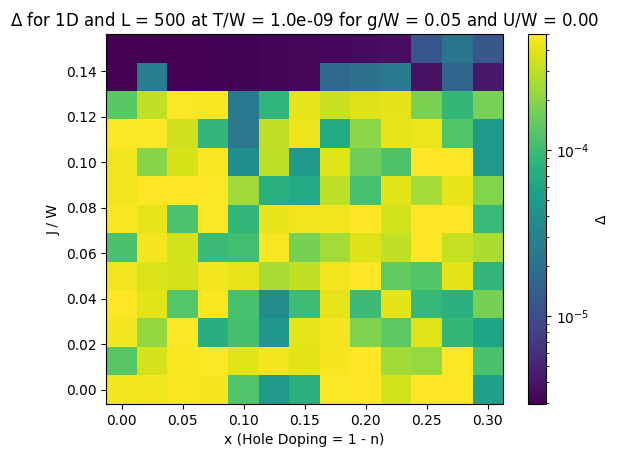

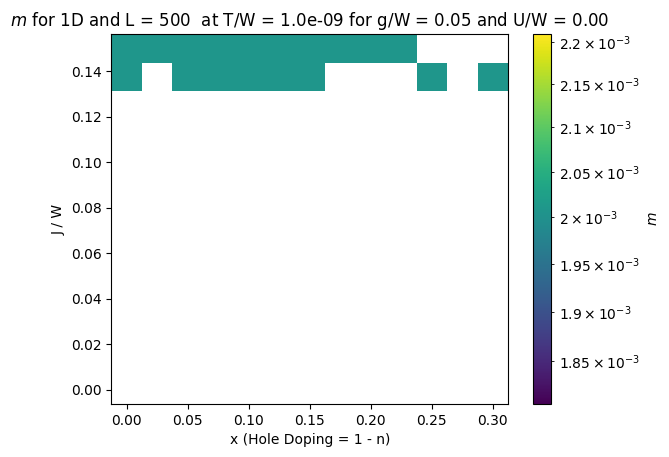

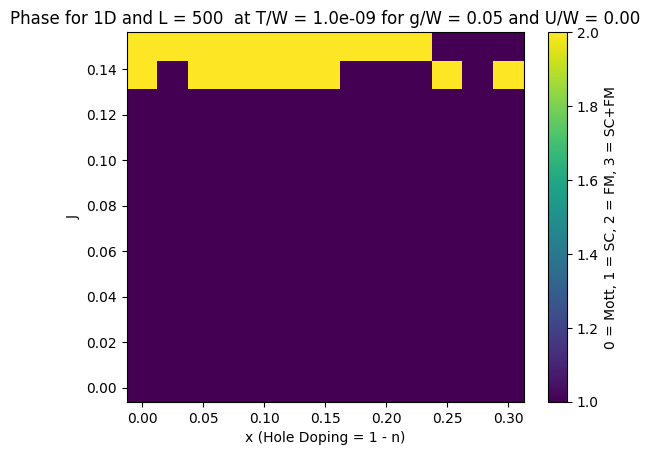

Step 1/13: computing for J / W = 0.00
Progress: 13/13
Step 2/13: computing for J / W = 0.01
Progress: 13/13
Step 3/13: computing for J / W = 0.02
Progress: 13/13
Step 4/13: computing for J / W = 0.04
Progress: 13/13
Step 5/13: computing for J / W = 0.05
Progress: 13/13
Step 6/13: computing for J / W = 0.06
Progress: 13/13
Step 7/13: computing for J / W = 0.07
Progress: 13/13
Step 8/13: computing for J / W = 0.09
Progress: 13/13
Step 9/13: computing for J / W = 0.10
Progress: 13/13
Step 10/13: computing for J / W = 0.11
Progress: 13/13
Step 11/13: computing for J / W = 0.12
Progress: 13/13
Step 12/13: computing for J / W = 0.14
Progress: 13/13
Step 13/13: computing for J / W = 0.15
Progress: 13/13


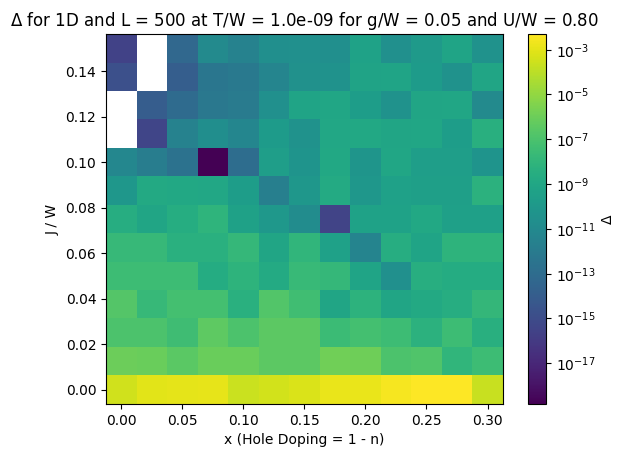

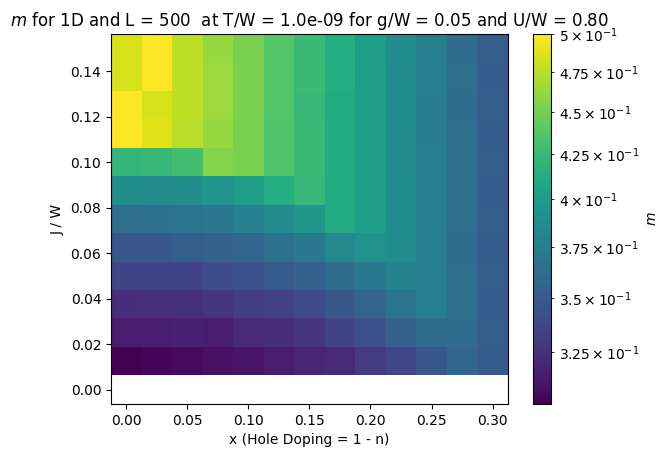

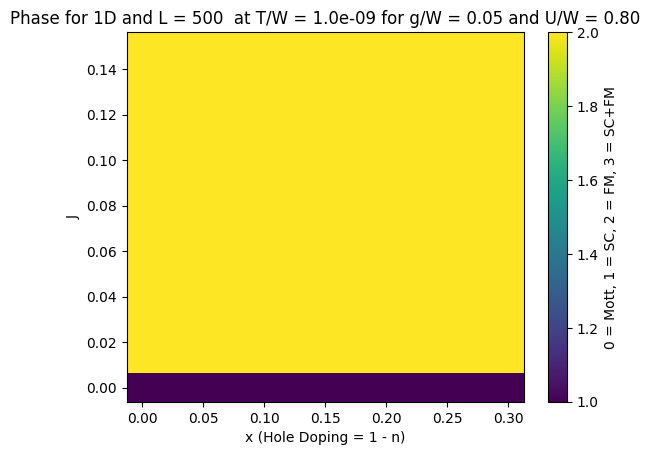

Step 1/13: computing for J / W = 0.00
Progress: 13/13
Step 2/13: computing for J / W = 0.01
Progress: 13/13
Step 3/13: computing for J / W = 0.02
Progress: 13/13
Step 4/13: computing for J / W = 0.04
Progress: 13/13
Step 5/13: computing for J / W = 0.05
Progress: 13/13
Step 6/13: computing for J / W = 0.06
Progress: 13/13
Step 7/13: computing for J / W = 0.07
Progress: 13/13
Step 8/13: computing for J / W = 0.09
Progress: 13/13
Step 9/13: computing for J / W = 0.10
Progress: 13/13
Step 10/13: computing for J / W = 0.11
Progress: 13/13
Step 11/13: computing for J / W = 0.12
Progress: 13/13
Step 12/13: computing for J / W = 0.14
Progress: 13/13
Step 13/13: computing for J / W = 0.15
Progress: 13/13


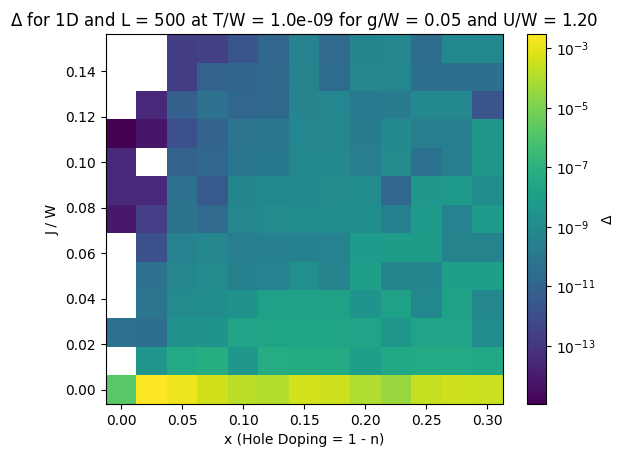

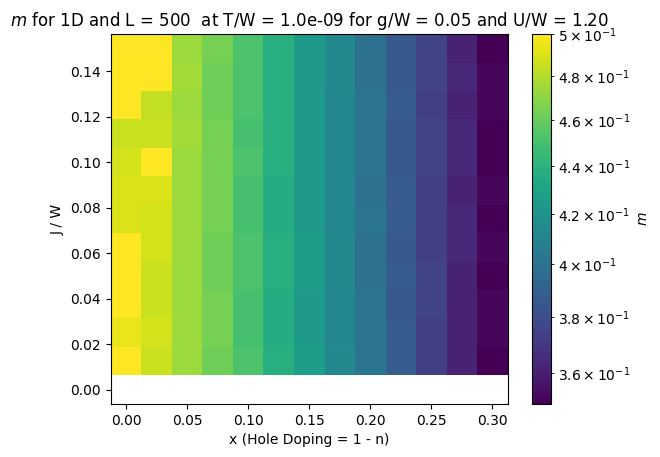

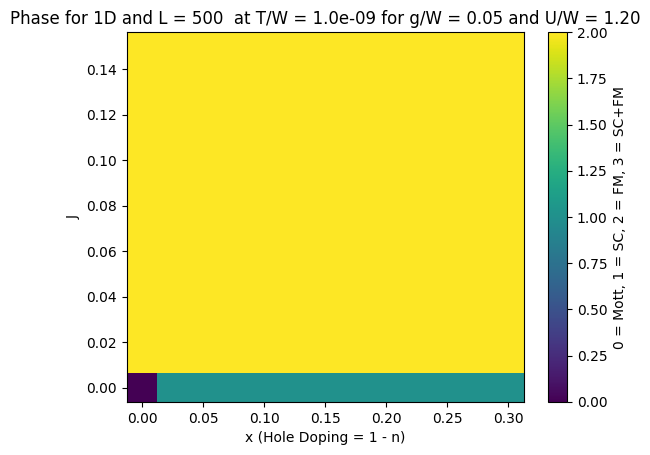

Step 1/13: computing for J / W = 0.00
Progress: 13/13
Step 2/13: computing for J / W = 0.01
Progress: 13/13
Step 3/13: computing for J / W = 0.02
Progress: 13/13
Step 4/13: computing for J / W = 0.04
Progress: 13/13
Step 5/13: computing for J / W = 0.05
Progress: 13/13
Step 6/13: computing for J / W = 0.06
Progress: 13/13
Step 7/13: computing for J / W = 0.07
Progress: 13/13
Step 8/13: computing for J / W = 0.09
Progress: 13/13
Step 9/13: computing for J / W = 0.10
Progress: 13/13
Step 10/13: computing for J / W = 0.11
Progress: 13/13
Step 11/13: computing for J / W = 0.12
Progress: 13/13
Step 12/13: computing for J / W = 0.14
Progress: 13/13
Step 13/13: computing for J / W = 0.15
Progress: 13/13


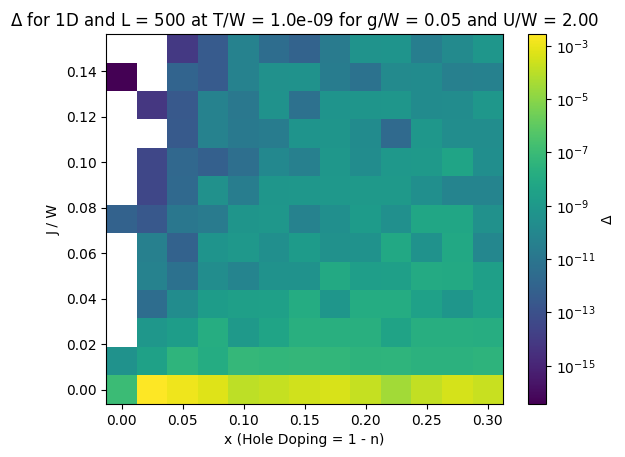

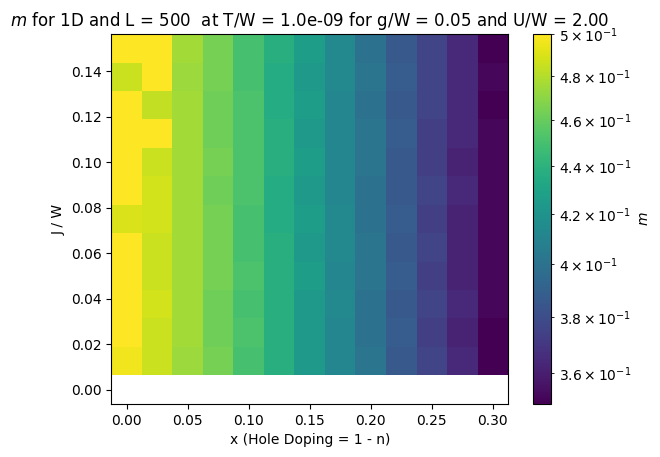

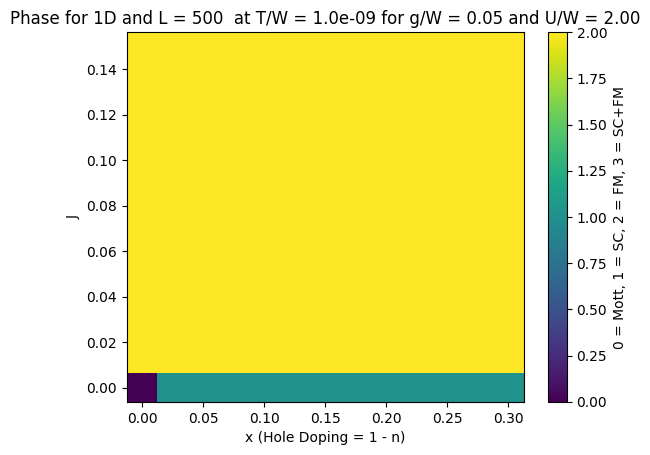

In [36]:
# CONSTANTS
d = 1
W = 4 * d

# PARAMETERS
L = 500
g = 0.05 * W
T = 1e-9 * W

# Hubbard 
uu = np.array([0.0, 0.8, 1.2, 2.0]) * W

# CALCULATION PARAMETERS
# We use higher errors while computing the chemical potential mu

# Delta
delta_start = 1e-2
delta_eps_mu = 1e-3
delta_eps = 1e-4
delta_zero_mult = 1e-2

# Magnetization
m_start = 1e-2
m_eps_mu = 1e-4
m_eps = 1e-5
m_zero_mult = 1e-3


# J Sweep
J_min = 0*W
J_max = 0.15 * W
J_ste = 13

jj = np.linspace(J_min, J_max, J_ste)


# X sweep
x_min = 0
x_max = 0.3
x_ste = 13

xx = np.linspace(x_min, x_max, x_ste)
mu_eps = 1e-3


# Calculations
for U in uu:

    # Make the mesh
    xx_mesh, jj_mesh = np.meshgrid(xx, jj)

    dd_mesh = np.zeros_like(jj_mesh)
    mm_mesh = np.zeros_like(jj_mesh)
    for ij, J in enumerate(jj):

        print(f"Step {ij + 1}/{J_ste}: computing for J / W = {J / W:.2f}")

        succ = 0
        for ix, x in enumerate(xx):

            # Target filling
            n_target = 1 - x

            # Bissect for mu
            mu_min = -W/2 - U - g - J - 0.1
            mu_max = U/2 + J + W

            mu = bissect(lambda mu_test: solve(L, d, mu_test, U, g, J, T, delta_start=delta_start, delta_eps=delta_eps_mu, m_start=m_start, m_eps=m_eps_mu)[1] - n_target, mu_min, mu_max, eps = mu_eps)
            
            # Solve for converged mu
            delta, n, fm, _, _ = solve(L, d, mu, U, g, J, T, delta_start=delta_start, delta_eps=delta_eps, m_start=m_start, m_eps=m_eps)

            # Save
            dd_mesh[ij, ix] = delta
            mm_mesh[ij, ix] = fm

            # Show progress
            print(f"\rProgress: {ix + 1}/{x_ste}", end="")

        # Reset print
        print("")
    
    # Set zeros to a fraction of the maximum value
    delta_zero = delta_zero_mult * np.max(dd_mesh)
    m_zero = m_zero_mult * np.max(mm_mesh)

    # Make the phase diagram
    pp_mesh = np.zeros_like(jj_mesh)
    pp_mesh += 1 * (dd_mesh > delta_zero)
    pp_mesh += 2 * (mm_mesh > m_zero)
    
    if np.max(dd_mesh) != 0:
        plt.title(f"$\\Delta$ for {d}D and L = {L} at T/W = {T/W:.1e} for g/W = {g/W:.2f} and U/W = {U/W:.2f}")
        plt.pcolormesh(xx_mesh, jj_mesh / W, dd_mesh, cmap="viridis", norm=colors.LogNorm(vmin=np.min(dd_mesh[dd_mesh > 0]), vmax=np.max(dd_mesh)))
        plt.colorbar(label="$\\Delta$")
        plt.xlabel("x (Hole Doping = 1 - n)")
        plt.ylabel("J / W")
        plt.show()

    if np.max(mm_mesh) != 0:
        plt.title(f"$m$ for {d}D and L = {L}  at T/W = {T/W:.1e} for g/W = {g/W:.2f} and U/W = {U/W:.2f}")
        plt.pcolormesh(xx_mesh, jj_mesh / W, mm_mesh, cmap="viridis", norm=colors.LogNorm(vmin=np.min(mm_mesh[mm_mesh > 0]), vmax=np.max(mm_mesh)))
        plt.colorbar(label="$m$")
        plt.xlabel("x (Hole Doping = 1 - n)")
        plt.ylabel("J / W")
        plt.show()

    plt.title(f"Phase for {d}D and L = {L}  at T/W = {T/W:.1e} for g/W = {g/W:.2f} and U/W = {U/W:.2f}")
    plt.pcolormesh(xx_mesh, jj_mesh / W, pp_mesh, cmap="viridis")
    plt.colorbar(label="0 = Mott, 1 = SC, 2 = FM, 3 = SC+FM")
    plt.xlabel("x (Hole Doping = 1 - n)")
    plt.ylabel("J")
    plt.show()

## Magnetic Order Testing

### Filling vs. Chemical Potential

In [ ]:
# CONSTANTS
d = 2
W = 4 * d

# PARAMETERS
L = 8000
U = 0
g = 0 * W
T = 1e-6 * W

jj = np.array([0.1, 0.5, 0.8]) * W

# CALCULATION PARAMETERS
# We use higher errors while computing the chemical potential mu

# Delta
delta_start = 1e-1
delta_eps_mu = 1e-3
delta_eps = 1e-4
delta_zero_mult = 1e-2

# Magnetization
m_start = 0.1
m_eps_mu = 1e-4
m_eps = 1e-5
m_zero_mult = 1e-2


# mu sweep
mu_min = -3.24
mu_max = -3.21
mu_ste = 100

mm = np.linspace(mu_min, mu_max, mu_ste)

# Compute
for ij, J in enumerate(jj):
    nn = []
    for im, mu in enumerate(mm):

        # Solve for fixed mu
        delta, n, fm, _, _ = solve(L, d, mu, U, g, J, T, delta_start=delta_start, delta_eps=delta_eps, m_start=m_start, m_eps=m_eps)

        # Save
        nn += [n]

    # Show progress
    print(f"\rProgress: {ij + 1}/{len(jj)}", end="")

    # Plot
    plt.title(f"Filling for {d}D and L = {L} at T/W = {T/W:.1e} for J/W = {J/W:.1f}, g/W = {g/W:.1f} and U/W = {U/W:.2f}")
    plt.plot(mm, nn, label=f"J/W = {J/W:.2f}")
    plt.xlabel("Chemical Potential")
    plt.ylabel("Filling")
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.show()

### Magnetization vs. Doping

In [ ]:
# CONSTANTS
d = 1
W = 4 * d

# PARAMETERS
L = 400
U = 2 * W
g = 0 * W
J = 0.15 * W
T = 1e-6 * W

# CALCULATION PARAMETERS
# We use higher errors while computing the chemical potential mu

# Delta
delta_start = 1e-1
delta_eps_mu = 1e-3
delta_eps = 1e-4
delta_zero_mult = 1e-2

# Magnetization
m_start = 0.1
m_eps_mu = 1e-5
m_eps = 1e-6
m_zero_mult = 1e-2


# X sweep
x_min = 0
x_max = 0.3
x_ste = 11

xx = np.linspace(x_min, x_max, x_ste)
mu_eps = 1e-3

# Compute
nn = []
ff = []
for ix, x in enumerate(xx):

    # Target filling
    n_target = 1 - x

    # Bissect for mu
    mu_min = -W/2 - U - g - J - mu_eps
    mu_max = U/2 + J + mu_eps

    mu = bissect(lambda mu_test: solve(L, d, mu_test, U, g, J, T, delta_start=delta_start, delta_eps=delta_eps_mu, m_start=m_start, m_eps=m_eps_mu)[1] - n_target, mu_min, mu_max, eps = mu_eps)
    
    # Solve for converged mu
    delta, n, fm, _, _ = solve(L, d, mu, U, g, J, T, delta_start=delta_start, delta_eps=delta_eps, m_start=m_start, m_eps=m_eps)

    # Save
    nn += [n]
    ff += [fm]

    # Show progress
    print(f"\rProgress: {ix + 1}/{x_ste}", end="")

# Plot
print(nn)
plt.title(f"Magnetization for {d}D and L = {L} at T/W = {T/W:.1e} for J/W = {J/W:.2f}, g/W = {g/W:.1f} and U/W = {U/W:.2f}")
plt.plot(xx, ff, label="Magnetization = $\\frac{1}{N_c}\\sum_i S_i^z$")
plt.xlabel("x (Hole Doping = 1 - n)")
plt.ylabel("Magnetization")
plt.show()

### Magnetization vs. Temperature

In [ ]:
# DIMENSIONS
d = 2
W = 4 * d


# PHYSICAL PARAMETERS
g = 0
U = 0
J = 100*W
mu = U/2


# CALCULATION PARAMETERS
L = 100


# Temperature Sweep (around the theoretical Tc)
tt_Tc = J * 2 * (1/4)

print(f"tt_Tc = {tt_Tc}")

tt_min = tt_Tc * 20
tt_max = tt_Tc / 20
tt_ste = 30

tt = np.logspace(np.log10(tt_min), np.log10(tt_max), tt_ste)


nn = []
ff = []
mm = []
for index, T in enumerate(tt):

    # Compute
    Delta, n, fm, _, _ = solve(L, d, mu, U, g, J, T, delta_start=0, m_start=0.01, m_eps=1e-6)

    # Theory
    try:
        m = bissect(lambda m: 0.5 * np.tanh(J * (2*d) * m / (2*T)) - m, 1e-5, 0.6, eps=1e-5)
    except ValueError:
        m = 0

    print(f"\rProgress: {index + 1}/{len(tt)}", end="")

    # Save
    nn += [n]
    ff += [fm]
    mm += [m]

plt.title(f"Magnetization for L = {L}, J = {J} and n = {np.average(nn):.2f} ± {np.std(nn):.2e}")
plt.plot(tt, ff, label="Magnetization = $\\frac{1}{N_c}\\sum_i S_i^z$")
plt.plot(tt, mm, label="Theory")
plt.xlabel("T (Temperature)")
plt.xscale("log")
plt.ylabel("Magnetization")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.show()

## Superfluid Stifness

In [ ]:
# CONSTANTS
d = 2
W = 4

# PARAMETERS
L = 64
J = 0
T = 0.001


# Mu SWEEP
mu_steps = 100

# g SWEEP
gg = [0.0, 3.0]

# U SWEEP
uu = [0.0, 12.0]

# Calculations
for U in uu:
    for g in gg:

        # Range of mu to compute
        mu_min = -2*d - U - g
        mu_max = -mu_min

        mm = np.linspace(mu_min, mu_max, mu_steps)

        nn = []
        ss = []
        for index, mu in enumerate(mm):

            # Solve the Hamiltonian
            Delta, n, fm, Kxx, _ = solve(L, d, mu, U, g, J, T)

            # Save the filling
            nn += [n]

            # Save the superfluid stifness
            ss += [Kxx]

            # Show progress
            # print(f"\rProgress: {index + 1}/{len(mm)}", end="")
        
        # print("")
        print(f"Done U = {U} and g = {g}")
            
        plt.plot(nn, ss, label=f"U = {U} and g = {g}")

plt.title(f"Kinetic Energy (L = {L}, d = {d}, T = {T})")
plt.xlabel("Filling")
plt.ylabel("Kinetic Energy")
plt.legend(bbox_to_anchor=(1.5, 1.))

## Filling $n(\mu)$ for a 1D Tight-Binding Chain

In [ ]:
# PARAMETERS
L = 500
d = 1
U = 0
g = 0
J = 0
T = 0.01


# MU SWEEP
mu_start = -2*d - U
mu_end = -mu_start
mu_steps = int(L/10)


# Calculations
mm = np.linspace(mu_start, mu_end, mu_steps+1)
nn = []
for mu in mm:

    # Solve the Hamiltonian
    Delta, n, _, _,  _ = solve(L, d, mu, U, g, J, T)

    # Save the filling
    nn += [n]

nn_theory = (2 / np.pi) * np.arccos(-0.5 * mm)

plt.title(f"Filling (L = {L}, d = {d}, U = {U}, g = {g}, T = {T})")
plt.ylabel("Filling")
plt.xlabel("Chemical Potential / t")
plt.plot(mm, nn, label="Calculations")
plt.plot(mm, nn_theory, label="Theory")
plt.legend()
plt.show()

plt.title("Error on previous plot")
plt.plot(mm, nn - nn_theory)
plt.ylabel("Filling")
plt.xlabel("Chemical Potential / t")
plt.show()